# PSBD end to end: from a checkpoint to a detection verdict

Notebook 05 covered the probe. This one runs the whole method on a single
checkpoint and follows every number from raw forward passes to a decision, with
nothing hidden behind a script.

## The method

PSBD asks how much a model's confidence in **its own prediction** falls when the
model is perturbed at inference time. The claim is that a backdoored model's
trigger-to-target path is unusually robust, so a poisoned input loses less
confidence than a clean one.

**Prediction Shift Uncertainty**, the per-sample score:

$$\phi_{PSU}(x) = P_c(x; \theta) - \frac{1}{k}\sum_{i=1}^{k} P_c(x; p, \theta_i')
\qquad c = \arg\max_c P(x; \theta)$$

In words: take the class the unperturbed model predicts, then subtract the average
probability the perturbed passes give **that same class**. The class is fixed by
the unperturbed pass, so the score measures robustness of a decision rather than
agreement between 2 predictions.

**Low PSU means poisoned.**

**Shift ratio**, a property of the disturbance rather than of a sample:

$$\sigma(D) = \frac{1}{k\,|D|}\sum_{x \in D}\sum_{i=1}^{k}
\mathbb{I}\left(Y(x;\theta) \neq Y(x;\theta_i')\right)$$

| symbol | meaning |
|---|---|
| $x$ | one input image |
| $\theta$ | the trained weights, unperturbed |
| $\theta_i'$ | the weights as seen through perturbed pass $i$ |
| $p$ | the perturbation rate |
| $k$ | number of perturbed passes |
| $c$ | the class the unperturbed model predicts |
| $P_c$ | softmax probability assigned to class $c$ |
| $Y$ | the argmax prediction |
| $\sigma(D)$ | fraction of all (sample, pass) predictions that moved, over split $D$ |

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in psbd resolves the same
# way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import logging

# compute_dropout_pass_probs reseeds on every call, and Lightning announces each
# one. In a sweep that is hundreds of identical lines between the results.
logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from psbd.config import DATASET_REGISTRY
from psbd.decision import (
    HEADLINE_QUANTILE,
    PSBD_QUANTILES,
    SHIFT_MATCH_TARGETS,
    detection_report,
    interpolate_at_target_shift,
    select_rate_adaptively,
    select_rate_at_matched_shift,
    select_rate_by_oracle,
    threshold_at_quantile,
)
from psbd.inference import build_baseline_cache, compute_dropout_pass_probs
from psbd.models import detect_architecture, load_checkpoint
from psbd.operators import build_perturbation
from psbd.positions import plug_dropout, unplug_dropout
from psbd.scores import (
    psu_from_cache,
    psu_ratio_from_cache,
    shift_ratio,
    shift_target_histogram,
)
from psbd.splits import build_psbd_loaders_from_checkpoint

CHECKPOINT = "checkpoints/vit_cifar100_badnet_a2o_0_01/attack_result.pt"
POSITION = "before_attention_norm"
OPERATOR = "token_mask"
FORWARD_PASSES = 6
RATES = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8)
MAX_SAMPLES = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## The 3 splits

The split is a plain shuffle of the clean test set with `seed_everything(0)`,
sliced in 2. There is no stratification and no per-class balancing.

- **validation**, the first 2000 of the permutation. Clean only. Its job is to set
  the detection threshold, and it is the only split a real defender is assumed to
  have. It never contains a triggered image.
- **clean** and **backdoor**, the rest of the permutation. These are **paired**:
  the same images, once untouched and once triggered. Pairing is what makes the
  comparison about the trigger rather than about which images happened to land in
  which split.

Leakage is impossible by construction, because validation and analysis are
disjoint slices of one permutation.

The backdoor split is slightly smaller than the clean one, and that is deliberate.
Attack success asks whether the trigger fools an image that is **not already** the
target class, so under all-to-one the images whose true class is the target are
dropped from the backdoor split. They are unanswerable rather than missing. The
backdoor rows stay an order-preserving subset of the clean rows, so the pairing
survives the drop.

In [2]:
loaders, manifest = build_psbd_loaders_from_checkpoint(CHECKPOINT, max_samples=MAX_SAMPLES)
architecture = detect_architecture(CHECKPOINT)
model = load_checkpoint(architecture, CHECKPOINT, device)
num_classes = DATASET_REGISTRY[manifest["dataset"]].num_classes

print("architecture:", architecture)
print("dataset:", manifest["dataset"], f"({num_classes} classes)")
print("probe attack:", manifest["probe_attack"], "target label", manifest["probe_target_label"])
print("label mode:", manifest["label_mode"])
for name, loader in loaders.items():
    print(f"  {name:11s} {len(loader.dataset):5d} images")

heldout = set(manifest["heldout_indices"])
analysis = set(manifest["analysis_clean_indices"])
print("validation and analysis disjoint:", heldout.isdisjoint(analysis))
clean_indices = manifest["analysis_clean_indices"]
backdoor_indices = manifest["analysis_backdoor_indices"]
print("backdoor rows are a subset of the clean rows:",
      set(backdoor_indices).issubset(clean_indices))
print("in the same order:",
      backdoor_indices == [i for i in clean_indices if i in set(backdoor_indices)])
print("clean rows dropped as ineligible:", len(set(clean_indices) - set(backdoor_indices)))

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


architecture: vit
dataset: cifar100 (100 classes)
probe attack: badnet_a2o target label 0
label mode: all_to_one
  validation   1000 images
  clean        1000 images
  backdoor      991 images
validation and analysis disjoint: True
backdoor rows are a subset of the clean rows: True
in the same order: True
clean rows dropped as ineligible: 9


## The unperturbed baseline

Every PSU is measured against this, so it is computed once, before any probe is
attached. It stores the full softmax, its argmax (the class $c$ the score
follows), and the label the loader asked for.

In [3]:
baselines = {
    name: build_baseline_cache(model, loader, device, use_bfloat16=True)
    for name, loader in loaders.items()
}
baseline_probs = {n: torch.cat([b["probs"] for b in c]) for n, c in baselines.items()}
baseline_labels = {n: torch.cat([b["labels"] for b in c]) for n, c in baselines.items()}
loader_labels = {n: torch.cat([b["loader_labels"] for b in c]) for n, c in baselines.items()}

summary = pd.DataFrame(
    [
        {
            "split": name,
            "samples": len(baseline_labels[name]),
            "mean_confidence": baseline_probs[name].max(dim=1).values.mean().item(),
            "agrees_with_loader_label": (baseline_labels[name] == loader_labels[name])
            .float()
            .mean()
            .item(),
        }
        for name in baselines
    ]
)
summary.round(4)

,split,samples,mean_confidence,agrees_with_loader_label
0,validation,1000,0.9217,0.818
1,clean,1000,0.9212,0.839
2,backdoor,991,0.9993,1.000


`agrees_with_loader_label` on the backdoor split is the attack success rate on
these images: the fraction where the trigger actually moved the prediction to the
attack's target. It matters because a triggered image the model still classifies
correctly is behaviourally clean, and counting it as a detection positive would
penalise the detector for the attack's failure rather than for its own miss.

## One rate, in full

Attach the probe, run `k` perturbed passes, and score every sample.

In [4]:
def run_rate(rate):
    handles = plug_dropout(
        model, architecture, (POSITION,), {POSITION: build_perturbation(OPERATOR)}, rate
    )
    try:
        # The model is NOT switched to train mode. compute_dropout_pass_probs
        # calls model.eval() itself, which keeps the model's own dropouts at
        # identity, and the probe is in train mode independently because it lives
        # outside the model tree. See notebook 05.
        measured = {}
        for name, loader in loaders.items():
            probs, argmax = compute_dropout_pass_probs(
                model, loader, baseline_labels[name], device,
                FORWARD_PASSES, True, seed=0,
            )
            measured[name] = {
                "psu": psu_from_cache(baseline_probs[name], baseline_labels[name], probs),
                "psu_ratio": psu_ratio_from_cache(
                    baseline_probs[name], baseline_labels[name], probs
                ),
                "sigma": shift_ratio(baseline_labels[name], argmax),
                "argmax": argmax,
            }
    finally:
        unplug_dropout(handles)
    return measured


single = run_rate(0.5)
for name, values in single.items():
    print(f"{name:11s} sigma {values['sigma']:.4f}   mean psu {values['psu'].mean():.4f}")

validation  sigma 0.8658   mean psu 0.8669
clean       sigma 0.8407   mean psu 0.8573
backdoor    sigma 0.0266   mean psu 0.1623


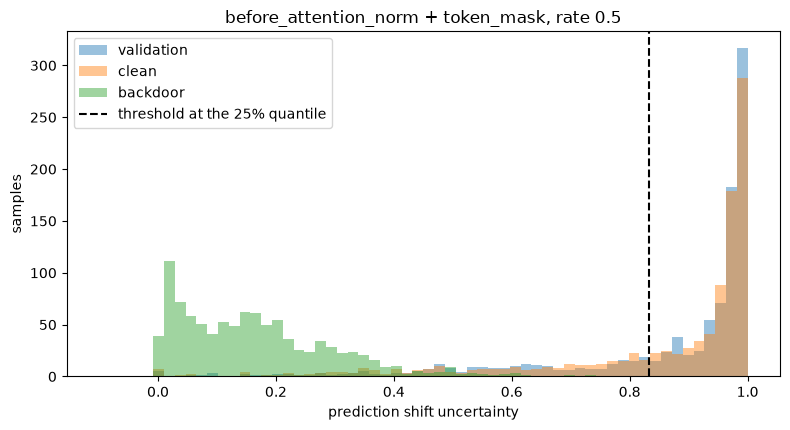

In [5]:
figure, axis = plt.subplots(figsize=(8, 4.4))
span = (-0.1, 1.0)
for name, style in (("validation", dict(alpha=0.45)), ("clean", dict(alpha=0.45)), ("backdoor", dict(alpha=0.45))):
    axis.hist(single[name]["psu"].numpy(), bins=60, range=span, label=name, **style)

threshold = threshold_at_quantile(single["validation"]["psu"], HEADLINE_QUANTILE)
axis.axvline(threshold, c="black", ls="--", lw=1.5,
             label=f"threshold at the {HEADLINE_QUANTILE:.0%} quantile")
axis.set_xlabel("prediction shift uncertainty")
axis.set_ylabel("samples")
axis.set_title(f"{POSITION} + {OPERATOR}, rate 0.5")
axis.legend()
figure.tight_layout()
plt.show()

Everything left of the dashed line is flagged as poisoned. The line's position is
chosen entirely from the clean validation split, which is why the method is
deployable: no backdoor data is needed to place it.

That also means **the false positive rate is set mechanically by the quantile**,
not discovered. Choosing the 25th percentile is choosing to tolerate about 25
percent clean loss. The interesting quantity is how much of the backdoor split
falls below the same line.

In [6]:
quantile_rows = [
    {"quantile": q, **detection_report(
        single["validation"]["psu"], single["clean"]["psu"], single["backdoor"]["psu"], q
    )}
    for q in PSBD_QUANTILES
]
pd.DataFrame(quantile_rows).drop(columns=["quantile"]).assign(
    quantile=[q for q in PSBD_QUANTILES]
).set_index("quantile").round(4)

,threshold,tpr,fpr,auroc,auroc_two_sided,direction
quantile,,,,,,
0.01,0.1414,0.4904,0.011,0.9817,0.9817,as_expected
0.05,0.4551,0.9677,0.070,0.9817,0.9817,as_expected
0.10,0.5671,0.9909,0.107,0.9817,0.9817,as_expected
0.15,0.6625,0.9980,0.149,0.9817,0.9817,as_expected
0.20,0.7781,1.0000,0.214,0.9817,0.9817,as_expected
0.25,0.8330,1.0000,0.271,0.9817,0.9817,as_expected


AUROC is identical in every row, because it is threshold free. Only TPR and FPR
move, and FPR tracks the quantile almost exactly, which is the check that the
threshold rule is behaving.

## Sweeping the rate

A single rate is one point on a curve. The rate controls how hard the model is hit,
and both the separation and the shift ratio depend on it.

In [7]:
swept = {rate: run_rate(rate) for rate in RATES}

sweep_rows = []
for rate, measured in swept.items():
    report = detection_report(
        measured["validation"]["psu"], measured["clean"]["psu"],
        measured["backdoor"]["psu"], HEADLINE_QUANTILE,
    )
    ratio_report = detection_report(
        measured["validation"]["psu_ratio"], measured["clean"]["psu_ratio"],
        measured["backdoor"]["psu_ratio"], HEADLINE_QUANTILE,
    )
    sweep_rows.append(
        {
            "rate": rate,
            "sigma_validation": measured["validation"]["sigma"],
            "auroc": report["auroc"],
            "tpr": report["tpr"],
            "fpr": report["fpr"],
            "auroc_fractional": ratio_report["auroc"],
            "direction": report["direction"],
        }
    )

sweep = pd.DataFrame(sweep_rows).set_index("rate")
sweep.round(4)

,sigma_validation,auroc,tpr,fpr,auroc_fractional,direction
rate,,,,,,
0.1,0.1255,0.6644,0.0565,0.262,0.6645,as_expected
0.2,0.2818,0.7989,0.8880,0.255,0.7991,as_expected
0.3,0.4853,0.8957,0.9909,0.276,0.8966,as_expected
0.4,0.7072,0.9613,0.9990,0.280,0.9627,as_expected
0.5,0.8658,0.9817,1.0000,0.271,0.9875,as_expected
0.6,0.9338,0.9624,1.0000,0.247,0.9958,as_expected
0.7,0.9690,0.8937,0.9778,0.250,0.9979,as_expected
0.8,0.9762,0.7809,0.6781,0.246,0.9800,as_expected


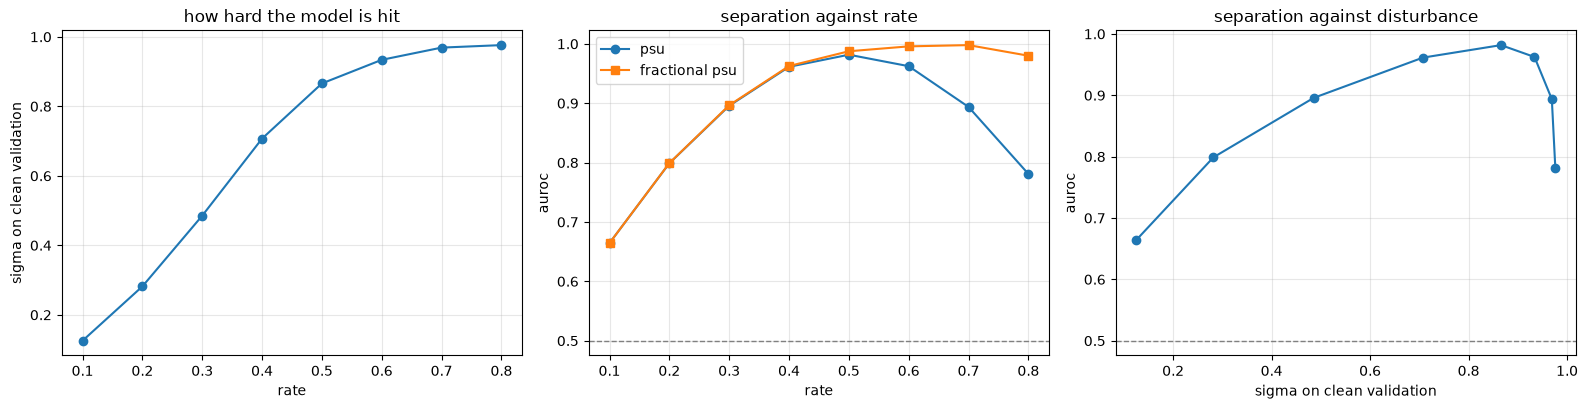

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(sweep.index, sweep["sigma_validation"], marker="o")
axes[0].set_xlabel("rate"); axes[0].set_ylabel("sigma on clean validation")
axes[0].set_title("how hard the model is hit")

axes[1].plot(sweep.index, sweep["auroc"], marker="o", label="psu")
axes[1].plot(sweep.index, sweep["auroc_fractional"], marker="s", label="fractional psu")
axes[1].axhline(0.5, ls="--", lw=1, c="grey")
axes[1].set_xlabel("rate"); axes[1].set_ylabel("auroc"); axes[1].legend()
axes[1].set_title("separation against rate")

axes[2].plot(sweep["sigma_validation"], sweep["auroc"], marker="o")
axes[2].axhline(0.5, ls="--", lw=1, c="grey")
axes[2].set_xlabel("sigma on clean validation"); axes[2].set_ylabel("auroc")
axes[2].set_title("separation against disturbance")
for axis in axes:
    axis.grid(alpha=0.3)
figure.tight_layout()
plt.show()

The third panel is the one that transfers across placements. Rate is a knob whose
meaning changes with position and operator, sigma is what the model experienced.

## Choosing a rate without looking at the answer

A defender cannot pick the rate that maximizes AUROC, because computing AUROC
needs the backdoor labels. `psbd.decision` implements 3 rules, and only the first
2 are legal.

In [9]:
shift_by_rate = {rate: m["validation"]["sigma"] for rate, m in swept.items()}
auroc_by_rate = dict(zip(sweep.index, sweep["auroc"]))

rules = {
    "adaptive, smallest rate reaching sigma 0.8": select_rate_adaptively(shift_by_rate),
    "oracle, the best rate in hindsight": select_rate_by_oracle(auroc_by_rate),
}
for target in SHIFT_MATCH_TARGETS:
    rules[f"matched shift, sigma {target}"] = select_rate_at_matched_shift(shift_by_rate, target)

rule_rows = [
    {
        "rule": name,
        "selected_rate": rate,
        "achieved_sigma": shift_by_rate.get(rate),
        "auroc": auroc_by_rate.get(rate),
        "defender_legal": "oracle" not in name,
    }
    for name, rate in rules.items()
]
pd.DataFrame(rule_rows).round(4)

,rule,selected_rate,achieved_sigma,auroc,defender_legal
0,"adaptive, smallest rate reaching sigma 0.8",0.5,0.8658,0.9817,True
1,"oracle, the best rate in hindsight",0.5,0.8658,0.9817,False
2,"matched shift, sigma 0.2",0.1,0.1255,0.6644,True
3,"matched shift, sigma 0.4",0.3,0.4853,0.8957,True
4,"matched shift, sigma 0.6",0.4,0.7072,0.9613,True
5,"matched shift, sigma 0.8",0.5,0.8658,0.9817,True


The gap between the oracle row and the legal rows is the cost of not knowing the
answer in advance. Reporting only the oracle row would overstate the method, and
that distinction is the single most important honesty point in the whole result
set.

`select_rate_at_matched_shift` snaps to the nearest swept rate, which can be some
distance from the target. When the achieved sigma matters,
`interpolate_at_target_shift` interpolates between the 2 bracketing rates instead.

In [10]:
interpolated = [
    {
        "target_sigma": target,
        "nearest_rate": select_rate_at_matched_shift(shift_by_rate, target),
        "nearest_sigma": shift_by_rate.get(select_rate_at_matched_shift(shift_by_rate, target)),
        "interpolated_auroc": interpolate_at_target_shift(shift_by_rate, auroc_by_rate, target),
    }
    for target in SHIFT_MATCH_TARGETS
]
pd.DataFrame(interpolated).round(4)

,target_sigma,nearest_rate,nearest_sigma,interpolated_auroc
0,0.2,0.1,0.1255,0.7285
1,0.4,0.3,0.4853,0.8551
2,0.6,0.4,0.7072,0.9296
3,0.8,0.5,0.8658,0.9733


## Testing the mechanism the original paper proposed

PSBD's stated explanation is a neuron-bias effect: under perturbation, clean
samples do not scatter across classes, they collapse onto the attacker's target,
because that is the strongest association the poisoned model learned.

That is a checkable claim. `shift_target_histogram` records which class each
shifted prediction landed on. A spike at the target class supports the account. A
flat histogram does not.

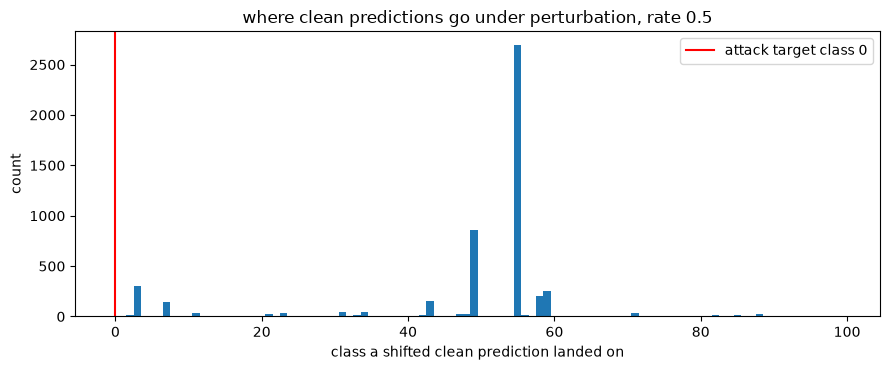

shifted clean predictions landing on the target class: 0.0000
uniform expectation if they scattered evenly:          0.0100
largest share taken by any single class:               0.5343
the class taking it:                                   55


In [11]:
best_rate = select_rate_adaptively(shift_by_rate) or 0.5
histogram = shift_target_histogram(
    baseline_labels["clean"], swept[best_rate]["clean"]["argmax"], num_classes
)
counts = np.array(histogram)
target = manifest["probe_target_label"]

figure, axis = plt.subplots(figsize=(9, 3.8))
axis.bar(range(num_classes), counts, width=1.0)
axis.axvline(target, c="red", lw=1.5, label=f"attack target class {target}")
axis.set_xlabel("class a shifted clean prediction landed on")
axis.set_ylabel("count")
axis.set_title(f"where clean predictions go under perturbation, rate {best_rate}")
axis.legend()
figure.tight_layout()
plt.show()

share = counts[target] / counts.sum() if counts.sum() else float("nan")
print(f"shifted clean predictions landing on the target class: {share:.4f}")
print(f"uniform expectation if they scattered evenly:          {1 / num_classes:.4f}")
print(f"largest share taken by any single class:               {counts.max() / counts.sum():.4f}")
print(f"the class taking it:                                   {int(counts.argmax())}")

Read the last 4 numbers together. If the target class share is close to the
uniform expectation, and some other class takes the largest share, then the
collapse-onto-target account is not what is happening on this model, whatever else
is true about the detection performance.

That matters for the paper's framing rather than for its numbers: the method can
work while the published explanation of why it works does not hold on this
architecture.

A second result points the same way and is recorded as H23 rather than shown
here: Gaussian noise, which removes no capacity at all and so has no neuron bias
story available to it, matches the best structured masks. An operator that cannot
possibly work by the proposed mechanism working just as well is hard to reconcile
with that mechanism being what carries the method.